In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import cartopy.crs as ccrs
import geopandas as gpd
#import rioxarray
import cartopy.feature as cf
#from rasterio.enums import Resampling


In [5]:
# load mean temperature station data
df = pd.read_csv('/home/queenle/hydro_attribution/station_data/temperature_17_series/Combined17SS_02.csv')
df['date'] = df['STATS_YEAR'].astype(str) + '-' + df['STATS_MONTH'].astype(str)
df.index = pd.to_datetime(df['date'])

df_list = []
for site in df['station'].unique():
    ts = df.loc[df['station']==site]['newval']
    ts = ts.rename(site)
    df_list.append(ts)
    
obs_df = pd.concat(df_list, axis=1)

# load station metadata
meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/temperature_17_series/17SS_meta.csv')
meta_df.loc[6,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell


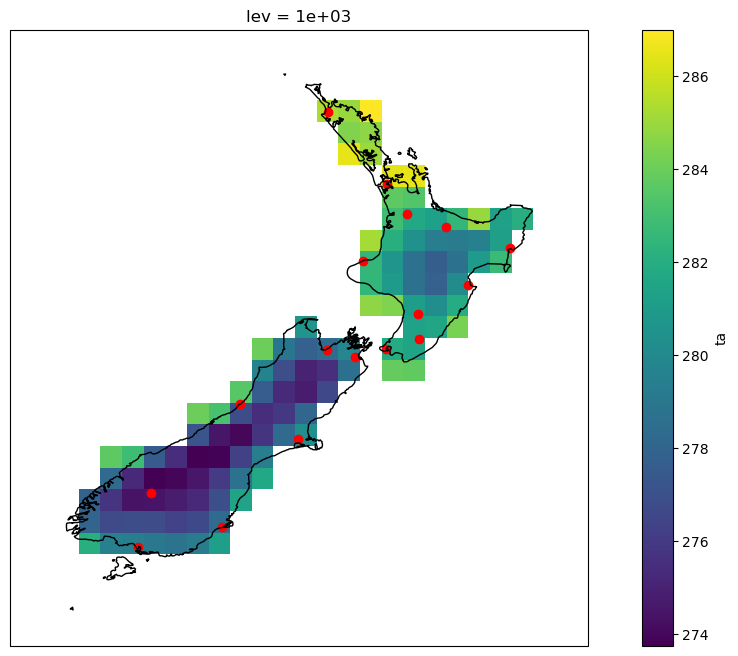

In [14]:
fig,axs = plt.subplots(figsize=(14,8),subplot_kw=dict(projection=ccrs.PlateCarree()))


var = 'TA'
direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'


ens_mem_season = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/TA/means/TA_Aday_d4PDF_HPB_FullEnsMean_raw_winter_1951-2011.nc')
ens_mem_season.mean('time').plot(ax=axs)

lats = []
lons = []
for site in obs_df.columns:
    lat,lon = meta_df.loc[meta_df['station']==site][['LAT','LONGT']].values[0]
    lats.append(lat)
    lons.append(lon)
    ts = ens_mem_season.interp(lat=lat,lon=lon)
    #print(ts)


axs.scatter(lons,lats,c='red')

axs.coastlines()
axs.add_feature(cf.BORDERS)
axs.set_extent([165,180, -49,-33])#, crs=noproj)


In [8]:
'''
Write ensemble member csv files with station-based TA time series
'''

def write_dataframe(direc,var,scen,number,s):
    
    ens_mem_season = xr.open_dataarray(direc+var+'/full/'+var+'_Amon_d4PDF_'+scen+'_m'+number+'_gaussian_'+s+'_1951-2021.nc')
    
    df_dict = {'time':ens_mem_season.time.values}
    for site in obs_df.columns:
        lat,lon = meta_df.loc[meta_df['station']==site][['LAT','LONGT']].values[0]

        ts = ens_mem_season.interp(lat=lat,lon=lon)
        if np.isnan(ts).any():
            ts = ens_mem_season.interp(lat=lat,lon=lon,method='nearest')

        df_dict[site] = ts

    df = pd.DataFrame(df_dict)
        
    df.to_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_m'+number+"_gaussian_"+s+'_1951-2021.csv')

    
var = 'TA'
direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'

for scen in ['HPB','HPB_NAT']:

    print(scen)

    for s in ['winter','spring','summer','autumn']:
        print(s)

        for ens_mem in range(1,101):
            print(ens_mem)
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

            write_dataframe(direc,var,scen,number,s)
            

HPB
winter
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
spring
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
summer
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
autumn
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34

In [9]:
'''
write mean files
'''

var = 'TA'
direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'

for scen in ['HPB','HPB_NAT']:

    for s in ['winter','spring','summer','autumn']:

        dfs = []
        for ens_mem in range(1,101):
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

            df = pd.read_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_m'+number+"_gaussian_"+s+'_1951-2021.csv')

            df = df.set_index('time').drop('Unnamed: 0',axis=1)
            
            dfs.append(df)
        
            
        ens_mean_df = sum(dfs)/len(dfs)
        ens_mean_df.to_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_ensMean_gaussian_'+s+'_1951-2021.csv')

/home/queenle/.local/lib/python3.6/site-packages/pandas/plotting/_matplotlib/core.py:1192: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)


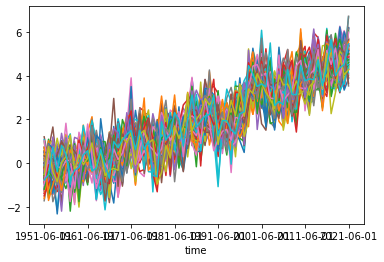

In [10]:
scen = 'HPB'
s = 'winter'

dfs = []
for ens_mem in range(1,101):

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

    df = pd.read_csv(direc+var+"/full/station_resolution/"+var+'_d4PDF_'+scen+'_m'+number+"_gaussian_"+s+'_1951-2021.csv')

    df = df.set_index('time')#.drop('Unnamed: 0',axis=1)

    df.mean(axis=1).plot()
    
    dfs.append(df)